In [32]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline



In [24]:
# read SBS_B and SBS_D to the decompose them 

denovos = pd.read_table('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/Sigs_288.txt',index_col=0)


sbs288B = denovos.loc[:,'SBS288B']
sbs288D = denovos.loc[:,'SBS288D']

sbs288B.name = 'SBS288A'

sbs288D.name = 'SBS288B'

In [25]:
pd.DataFrame([sbs288B,sbs288D]).T.to_csv('Fig1/sigs_for_decomposing.txt',
                                        sep='\t')

In [26]:
pd.DataFrame([sbs288B,sbs288D]).T

,SBS288A,SBS288B
MutationType,,
T:A[C>A]A,0.008185,0.001898
T:A[C>A]C,0.001451,0.002619
T:A[C>A]G,0.000559,0.000178
T:A[C>A]T,0.002974,0.001724
T:A[C>G]A,0.000313,0.000720
...,...,...
N:T[T>C]T,0.002265,0.010474
N:T[T>G]A,0.000518,0.000349
N:T[T>G]C,0.000107,0.000441


In [27]:
######### Figure 1a-b ##########

# decompose SBS_B AND SBS_D
# SBS288A = SBS_B
# SBS288B = SBS_D
# produces pdfs of the 2 plots

from SigProfilerAssignment import Analyzer as Analyze
Analyze.decompose_fit(samples="/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/MSA_testing_SBS96B/mutographs_SBS288_extraction/Samples.txt", 
                      output="Fig1/",
                      input_type="matrix",
                      signatures="Fig1/sigs_for_decomposing.txt",
                      genome_build="GRCh38",
                      # need to filter out the signatures 
                      exclude_signature_subgroups=['Artifact_signatures','UV_signatures',
                               'Lymphoid_signatures','MMR_deficiency_signatures','POL_deficiency_signatures',
                                                  'BER_deficiency_signatures','Treatment_signatures'],
                      context_type="288",collapse_to_SBS96=True,
                      
                     )


 Decomposing De Novo Signatures  .....
Decompositon Plot:SBS288A |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (31829.91/s) 
Decompositon Plot:SBS288B |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (36309.50/s) 

 Assigning decomposed signature
|████████████████████████████████████████| 802/802 [100%] in 4.9s (164.14/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 


In [28]:
######### Figure 1c ##########

sbs18 = pd.read_table('/Users/kazachkova/Downloads/COSMIC_v3.4_SBS_GRCh38.txt',index_col=0).loc[:,'SBS18']


In [29]:
denovos = pd.read_table('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/Sigs_288.txt',index_col=0)

# need the 96 context to compare to SBS18
denovos.index = denovos.index.str.split(':').str[1]
denovos = denovos.groupby(denovos.index).sum()


sbs288B = denovos.loc[:,'SBS288B']
sbs288D = denovos.loc[:,'SBS288D']

sbs288B.name = 'SBS_B'

sbs288D.name = 'SBS_D'

alls = pd.concat([sbs18,sbs288B,sbs288D],axis=1)

alls_ca = alls[alls.index.str.contains('C>A')]

alls_ca_normed = (alls_ca / alls_ca.sum())

alls_ca_normed.corr(method='spearman')

,SBS18,SBS_B,SBS_D
SBS18,1.000000,0.970588,0.717647
SBS_B,0.970588,1.000000,0.697059
SBS_D,0.717647,0.697059,1.000000


In [30]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(alls_ca_normed.T)
similarity_df = pd.DataFrame(similarity_matrix, index=alls_ca_normed.T.index, columns=alls_ca_normed.T.index)

similarity_df

,SBS18,SBS_B,SBS_D
SBS18,1.000000,0.984847,0.800253
SBS_B,0.984847,1.000000,0.812674
SBS_D,0.800253,0.812674,1.000000


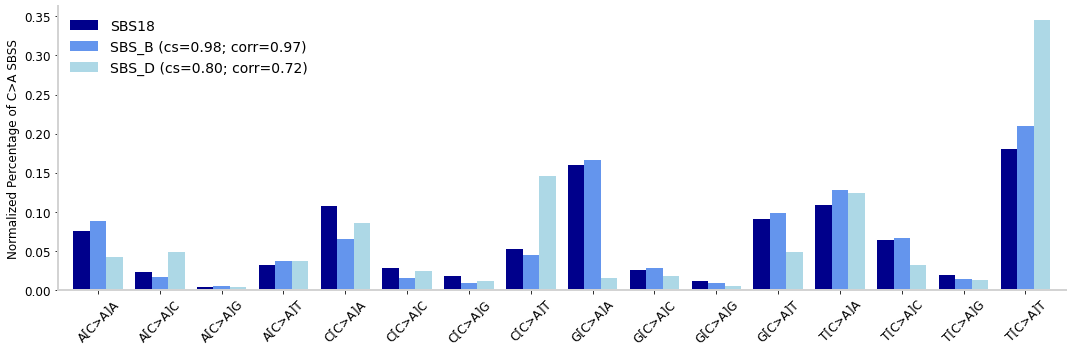

In [34]:
fig,ax = plt.subplots(figsize=(15,5))
alls_ca_normed.plot.bar(ax=ax,
                       width=.8,
                        color=['darkblue','cornflowerblue','lightblue'] )
plt.ylabel('Normalized Percentage of C>A SBSS')
plt.legend(fontsize=14,frameon=False,labels=['SBS18','SBS_B (cs=0.98; corr=0.97)','SBS_D (cs=0.80; corr=0.72)'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(12)

plt.xticks(rotation=45)
    
plt.tight_layout()

# plt.savefig('plots_for_paper/C_A_for_18_B_D.png',dpi=300)